# Heart Disease Prediction
## Binary Classification using the UCI Heart Disease Dataset

**Objective:** Build a machine learning model to predict whether a patient is at risk of heart disease based on clinical health data.

### Dataset Overview
The **Heart Disease UCI Dataset** contains 14 key features collected from patients at the Cleveland Clinic. The target variable (`target`) is binary:
- `0` → No heart disease
- `1` → Heart disease present

### Workflow
1. Import Libraries
2. Load & Inspect the Dataset
3. Data Cleaning
4. Exploratory Data Analysis (EDA)
5. Feature Engineering & Preprocessing
6. Model Training (Logistic Regression + Decision Tree)
7. Model Evaluation (Accuracy, Confusion Matrix, ROC-AUC)
8. Feature Importance Analysis

---
## 1. Import Libraries

We begin by importing all the necessary libraries for data manipulation, visualization, and machine learning.

In [33]:
# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & Model Selection
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    ConfusionMatrixDisplay
)

# Settings
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 120

print("All libraries imported successfully!")

All libraries imported successfully!


---
## 2. Load & Inspect the Dataset

We load the dataset directly from a URL (UCI/Kaggle mirror). If you downloaded it from Kaggle, replace the URL with the local path:
```python
df = pd.read_csv('heart.csv')
```

### Feature Dictionary
| Column | Description |
|--------|-------------|
| `age` | Age in years |
| `sex` | Sex (1 = male, 0 = female) |
| `cp` | Chest pain type (0–3) |
| `trestbps` | Resting blood pressure (mmHg) |
| `chol` | Serum cholesterol (mg/dl) |
| `fbs` | Fasting blood sugar > 120 mg/dl (1 = true) |
| `restecg` | Resting ECG results (0–2) |
| `thalach` | Maximum heart rate achieved |
| `exang` | Exercise-induced angina (1 = yes) |
| `oldpeak` | ST depression induced by exercise |
| `slope` | Slope of the peak exercise ST segment |
| `ca` | Number of major vessels colored by fluoroscopy (0–4) |
| `thal` | Thalassemia (0 = normal; 1 = fixed defect; 2 = reversible defect) |
| `target` | **Target: 1 = Heart disease, 0 = No disease** |

In [ ]:
# Load dataset (UCI Heart Disease - Cleveland)
url = "https://raw.githubusercontent.com/dsrscientist/dataset1/master/heartdisease.csv"

try:
    df = pd.read_csv(url)
    print("Dataset loaded from URL")
except Exception:
    # Fallback: load locally
    df = pd.read_csv('heart-disease-uci.csv')
    print("Dataset loaded from local file")

# Standardise column names if needed
df.columns = df.columns.str.lower().str.strip()

print(f"\nDataset Shape: {df.shape}")
print(f"Rows: {df.shape[0]}  |  Columns: {df.shape[1]}")
df.head()

Dataset loaded from local file

Dataset Shape: (920, 16)
Rows: 920  |  Columns: 16


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [35]:
# Basic info
print("=" * 50)
print("DATASET INFO")
print("=" * 50)
df.info()

DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [36]:
# Statistical summary
print("Statistical Summary:")
df.describe().round(2)

Statistical Summary:


,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.00,920.00,861.00,890.00,865.00,858.00,309.00,920.00
mean,460.50,53.51,132.13,199.13,137.55,0.88,0.68,1.00
std,265.73,9.42,19.07,110.78,25.93,1.09,0.94,1.14
min,1.00,28.00,0.00,0.00,60.00,-2.60,0.00,0.00
25%,230.75,47.00,120.00,175.00,120.00,0.00,0.00,0.00
50%,460.50,54.00,130.00,223.00,140.00,0.50,0.00,1.00
75%,690.25,60.00,140.00,268.00,157.00,1.50,1.00,2.00
max,920.00,77.00,200.00,603.00,202.00,6.20,3.00,4.00


---
## 3. Data Cleaning

Before modelling, we need to:
- Check for and handle **missing values**
- Check for and handle **duplicate rows**
- Verify **data types** are correct
- Identify any **outliers** that may distort the model

In [37]:
# --- Missing Values ---
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).query('`Missing Count` > 0')

if missing_df.empty:
    print("No missing values found! Dataset is clean.")
else:
    print("Missing values detected:")
    print(missing_df)
    # Impute: median for numerical, mode for categorical
    for col in missing_df.index:
        if df[col].dtype == 'object':
            df[col].fillna(df[col].mode()[0], inplace=True)
        else:
            df[col].fillna(df[col].median(), inplace=True)
    print("Missing values imputed.")

Missing values detected:
          Missing Count  Missing %
trestbps             59       6.41
chol                 30       3.26
fbs                  90       9.78
restecg               2       0.22
thalch               55       5.98
exang                55       5.98
oldpeak              62       6.74
slope               309      33.59
ca                  611      66.41
thal                486      52.83
Missing values imputed.


In [38]:
# --- Duplicate Rows ---
dupes = df.duplicated().sum()
print(f"Duplicate rows found: {dupes}")
if dupes > 0:
    df.drop_duplicates(inplace=True)
    print(f"Duplicates removed. New shape: {df.shape}")
else:
    print("No duplicates found.")

# --- Ensure target is binary 0/1 ---
# Some versions of the UCI dataset use values 0-4; we convert to binary
if 'target' in df.columns:
    df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)
    print(f"\nTarget distribution after binarisation:\n{df['target'].value_counts()}")

Duplicate rows found: 0
No duplicates found.


---
## 4. Exploratory Data Analysis (EDA)

EDA helps us understand the data distribution, detect patterns, and identify features that are most predictive of heart disease.

We will explore:
- **Target class distribution** (balanced vs imbalanced?)
- **Distributions of key features** by target class
- **Correlation heatmap** to detect multicollinearity
- **Categorical feature breakdowns**

In [39]:
# ── 1. Rename columns to match the notebook ──────────────────────────────────
df.rename(columns={'thalch': 'thalach', 'num': 'target'}, inplace=True)

# ── 2. Drop unhelpful columns ─────────────────────────────────────────────────
df.drop(columns=['id', 'dataset'], inplace=True)

# ── 3. Binarise target (0 = no disease, 1 = disease) ─────────────────────────
df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)

# ── 4. Encode string categoricals to numbers ──────────────────────────────────
df['sex'] = df['sex'].map({'Male': 1, 'Female': 0})

df['cp'] = df['cp'].map({
    'typical angina':    0,
    'atypical angina':   1,
    'non-anginal':       2,
    'asymptomatic':      3
})

df['restecg'] = df['restecg'].map({
    'normal':           0,
    'st-t abnormality': 1,
    'lv hypertrophy':   2
})

df['slope'] = df['slope'].map({
    'upsloping':   0,
    'flat':        1,
    'downsloping': 2
})

df['thal'] = df['thal'].map({
    'normal':           0,
    'fixed defect':     1,
    'reversable defect': 2
})

# ── 5. Convert booleans → int ─────────────────────────────────────────────────
df['fbs']   = df['fbs'].astype(int)
df['exang'] = df['exang'].astype(int)

# ── 6. Handle missing values ──────────────────────────────────────────────────
print("Missing values before imputation:")
print(df.isnull().sum()[df.isnull().sum() > 0])

for col in df.columns:
    if df[col].isnull().any():
        if df[col].dtype in ['float64', 'int64']:
            df[col].fillna(df[col].median(), inplace=True)
        else:
            df[col].fillna(df[col].mode()[0], inplace=True)

# ── 7. Verify ─────────────────────────────────────────────────────────────────
print("\nCleaning done!")
print(f"Shape: {df.shape}")
print(f"\nTarget distribution:\n{df['target'].value_counts()}")
print(f"\nDtypes:\n{df.dtypes}")
df.head()

Missing values before imputation:
Series([], dtype: int64)

Cleaning done!
Shape: (920, 14)

Target distribution:
target
1    509
0    411
Name: count, dtype: int64

Dtypes:
age           int64
sex           int64
cp            int64
trestbps    float64
chol        float64
fbs           int64
restecg       int64
thalach     float64
exang         int64
oldpeak     float64
slope         int64
ca          float64
thal          int64
target        int64
dtype: object


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,0,145.0,233.0,1,2,150.0,0,2.3,2,0.0,1,0
1,67,1,3,160.0,286.0,0,2,108.0,1,1.5,1,3.0,0,1
2,67,1,3,120.0,229.0,0,2,129.0,1,2.6,1,2.0,2,1
3,37,1,2,130.0,250.0,0,0,187.0,0,3.5,2,0.0,0,0
4,41,0,1,130.0,204.0,0,2,172.0,0,1.4,0,0.0,0,0


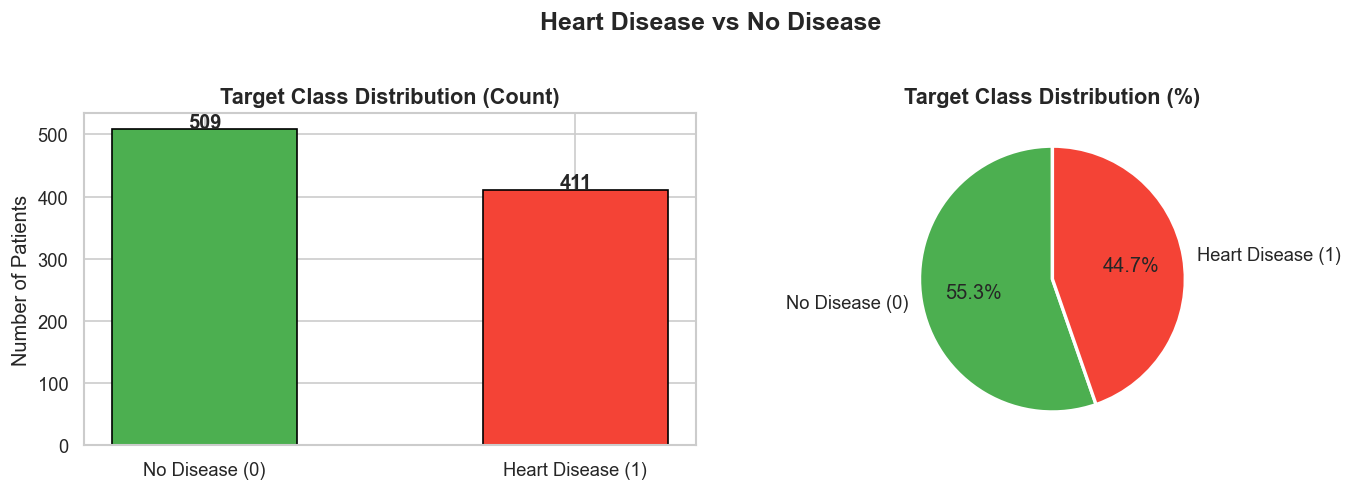


Class balance: 55.3% positive cases


In [40]:
# --- Target Class Distribution ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

target_counts = df['target'].value_counts()
labels = ['No Disease (0)', 'Heart Disease (1)']
colors = ['#4CAF50', '#F44336']

# Bar chart
axes[0].bar(labels, target_counts.values, color=colors, edgecolor='black', width=0.5)
axes[0].set_title('Target Class Distribution (Count)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Patients')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(target_counts.values, labels=labels, autopct='%1.1f%%',
            colors=colors, startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Target Class Distribution (%)', fontsize=13, fontweight='bold')

plt.suptitle('Heart Disease vs No Disease', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print(f"\nClass balance: {target_counts[1]/(target_counts.sum())*100:.1f}% positive cases")

In [41]:
print(df.columns.tolist())
print(df.head(2))

['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']
   age  sex  cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0   63    1   0     145.0  233.0    1        2    150.0      0      2.3   
1   67    1   3     160.0  286.0    0        2    108.0      1      1.5   

   slope   ca  thal  target  
0      2  0.0     1       0  
1      1  3.0     0       1  


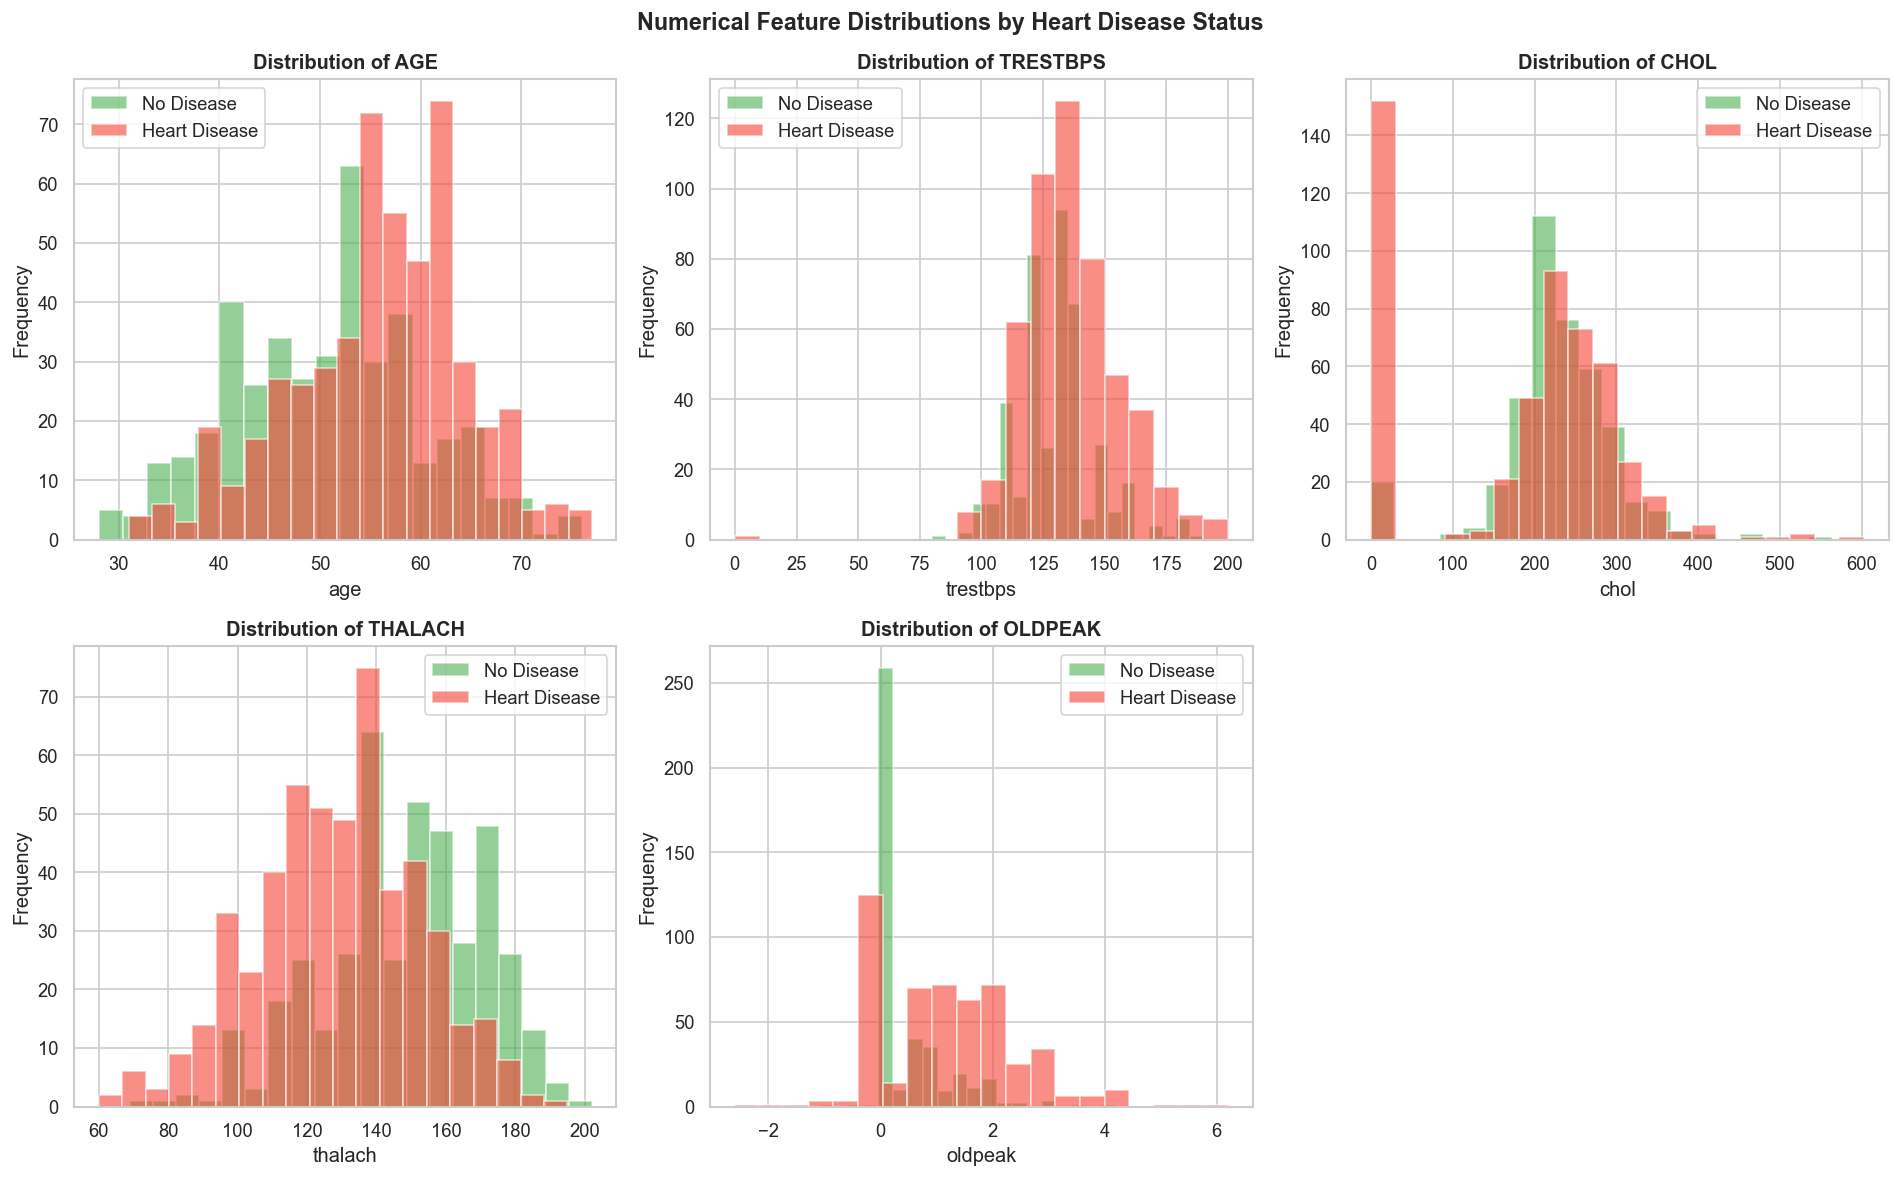

In [42]:
# --- Distribution of Numerical Features by Target ---
num_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, feature in enumerate(num_features):
    if feature in df.columns:
        for target_val, color, label in zip([0, 1], ['#4CAF50', '#F44336'], ['No Disease', 'Heart Disease']):
            subset = df[df['target'] == target_val][feature].dropna()
            axes[i].hist(subset, bins=20, alpha=0.6, color=color, label=label, edgecolor='white')
        axes[i].set_title(f'Distribution of {feature.upper()}', fontweight='bold')
        axes[i].set_xlabel(feature)
        axes[i].set_ylabel('Frequency')
        axes[i].legend()

# Hide unused subplot
axes[-1].set_visible(False)
plt.suptitle('Numerical Feature Distributions by Heart Disease Status', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

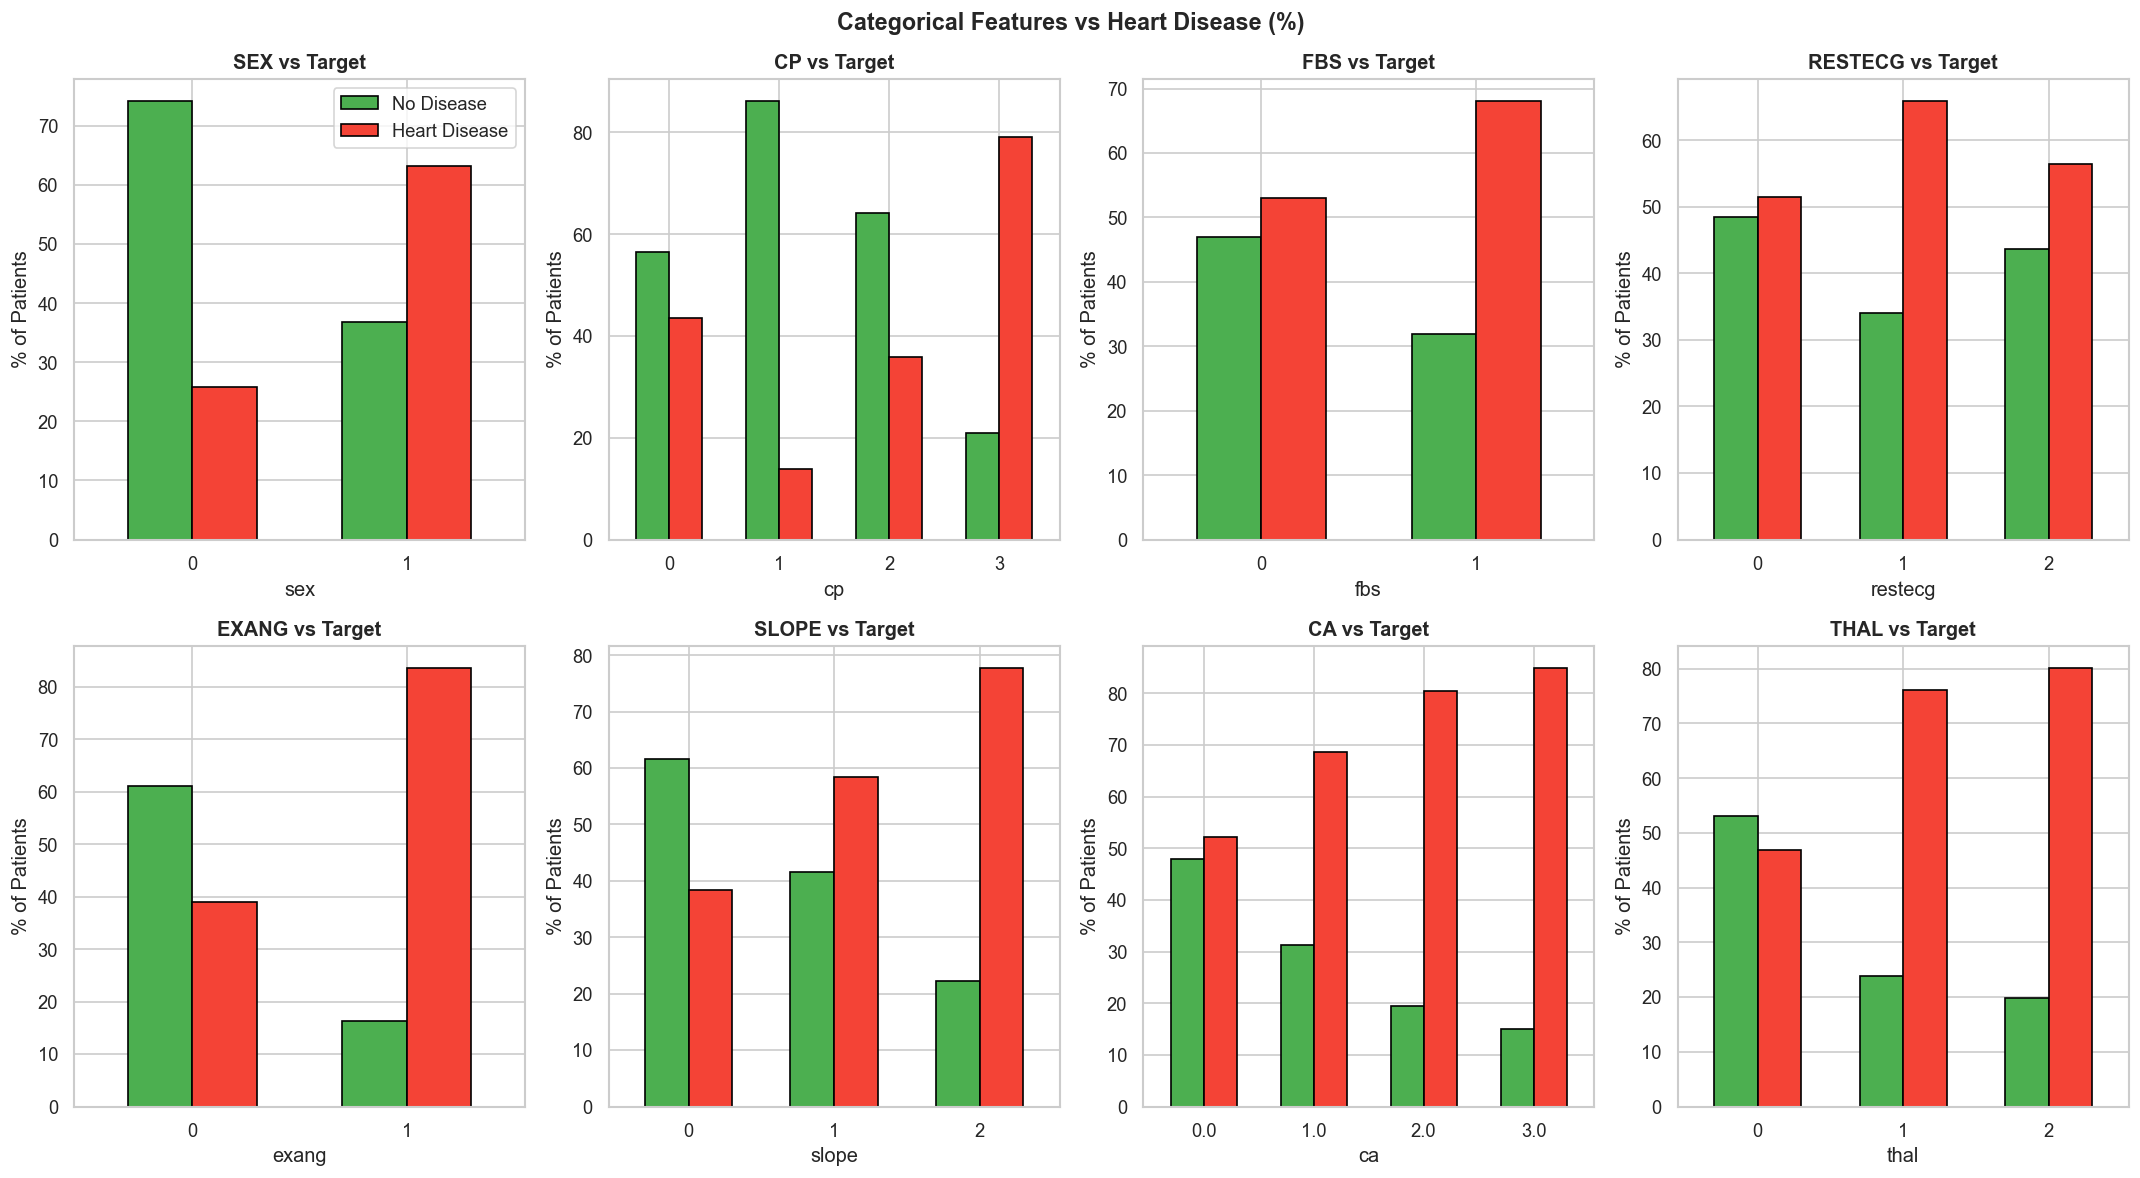

In [43]:
# --- Categorical Features vs Target ---
cat_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
cat_features = [f for f in cat_features if f in df.columns]

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

labels_map = {
    'sex': {0: 'Female', 1: 'Male'},
    'fbs': {0: 'FBS ≤ 120', 1: 'FBS > 120'},
    'exang': {0: 'No Angina', 1: 'Angina'},
}

for i, feature in enumerate(cat_features):
    ct = pd.crosstab(df[feature], df['target'], normalize='index') * 100
    ct.plot(kind='bar', ax=axes[i], color=['#4CAF50', '#F44336'],
            edgecolor='black', width=0.6, legend=(i == 0))
    axes[i].set_title(f'{feature.upper()} vs Target', fontweight='bold')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('% of Patients')
    axes[i].tick_params(axis='x', rotation=0)
    if i == 0:
        axes[i].legend(['No Disease', 'Heart Disease'], loc='upper right')

plt.suptitle('Categorical Features vs Heart Disease (%)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

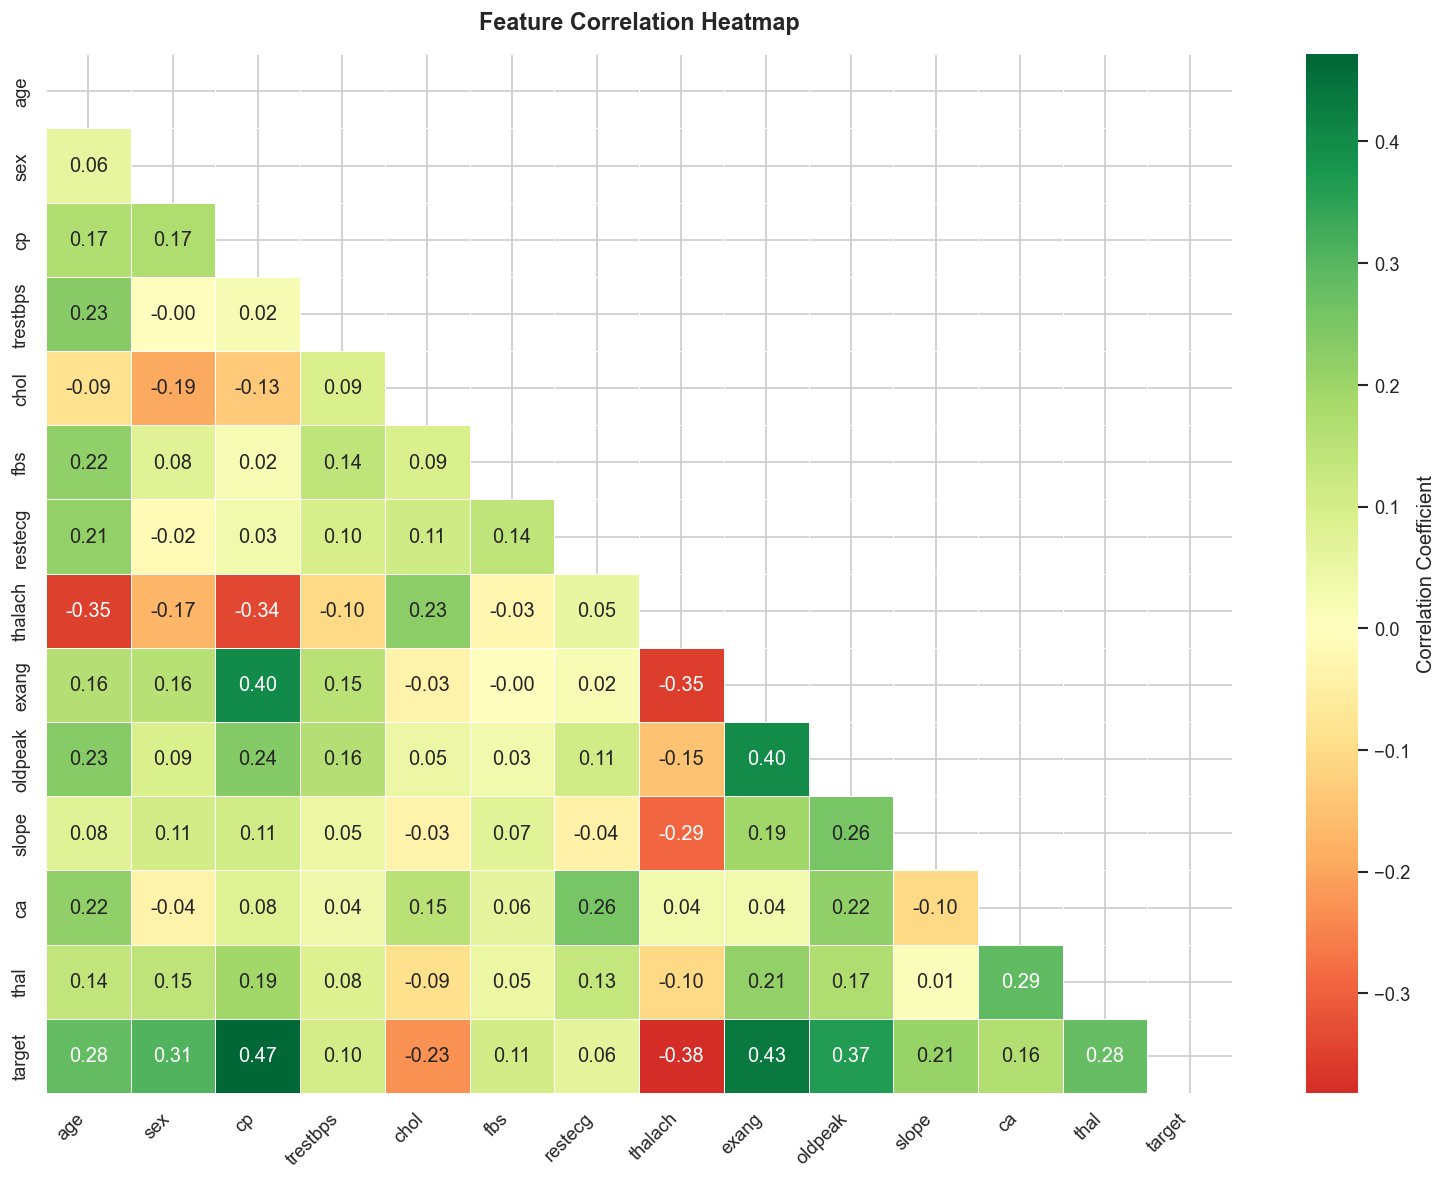


Top features correlated with TARGET:
cp          0.472
exang       0.434
thalach     0.382
oldpeak     0.366
sex         0.307
age         0.283
thal        0.281
chol        0.229
slope       0.205
ca          0.165
fbs         0.108
trestbps    0.101
restecg     0.062
Name: target, dtype: float64


In [44]:
# --- Correlation Heatmap ---
plt.figure(figsize=(13, 10))
corr = df.corr(numeric_only=True)

mask = np.triu(np.ones_like(corr, dtype=bool))  # Show only lower triangle
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0,
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'Correlation Coefficient'}
)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Top correlations with target
print("\nTop features correlated with TARGET:")
print(corr['target'].drop('target').abs().sort_values(ascending=False).round(3))

### EDA Key Insights

From the EDA above, we can observe:
- **`thalach` (max heart rate)** — patients with heart disease tend to achieve higher max heart rates during exercise, suggesting cardiac stress.
- **`cp` (chest pain type)** — certain types of chest pain are strongly associated with heart disease presence.
- **`oldpeak` (ST depression)** — higher ST depression values are more common in patients with heart disease.
- **`ca` (major vessels)** — more blocked vessels correlates strongly with disease.
- **`exang` (exercise angina)** — patients with angina during exercise are more likely to have heart disease.
- The dataset is relatively **balanced**, so we don't need to apply class-balancing techniques.

---
## 5. Feature Engineering & Preprocessing

Before training:
1. **Separate features (X) from target (y)**
2. **Split into training and test sets** (80/20 split)
3. **Scale numerical features** using `StandardScaler` — this is critical for Logistic Regression which is sensitive to feature magnitude

In [45]:
# --- Feature / Target Split ---
X = df.drop('target', axis=1)
y = df['target']

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape:  {y.shape}")
print(f"\nFeatures used:\n{list(X.columns)}")

Feature matrix shape: (920, 13)
Target vector shape:  (920,)

Features used:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


In [46]:
# --- Train/Test Split (80/20, stratified) ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set:   {X_train.shape[0]} samples")
print(f"Test set:       {X_test.shape[0]} samples")
print(f"\nClass distribution in training set:\n{y_train.value_counts()}")
print(f"\nClass distribution in test set:\n{y_test.value_counts()}")

Training set:   736 samples
Test set:       184 samples

Class distribution in training set:
target
1    407
0    329
Name: count, dtype: int64

Class distribution in test set:
target
1    102
0     82
Name: count, dtype: int64


In [47]:
# --- Feature Scaling ---
# StandardScaler: transforms features to mean=0, std=1
# We fit on training data ONLY to avoid data leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Features scaled (mean=0, std=1)")
print(f"Example — 'age' before scaling: mean={X_train['age'].mean():.1f}, std={X_train['age'].std():.1f}")
print(f"Example — 'age' after scaling:  mean≈0.00, std≈1.00")

Features scaled (mean=0, std=1)
Example — 'age' before scaling: mean=53.6, std=9.4
Example — 'age' after scaling:  mean≈0.00, std≈1.00


---
## 6. Model Training

We train two classification models and compare their performance:

### 6.1 Logistic Regression
A linear model that estimates the probability of class membership. It's interpretable, fast, and works well when the relationship between features and target is approximately linear.

### 6.2 Decision Tree Classifier
A non-linear model that splits data based on feature thresholds. It's highly interpretable (can be visualised) and handles non-linear patterns, but is prone to overfitting without depth control.

In [48]:
# --- 6.1 Logistic Regression ---
lr_model = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
lr_model.fit(X_train_scaled, y_train)

lr_pred  = lr_model.predict(X_test_scaled)
lr_proba = lr_model.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression trained.")
print(f"   Training Accuracy: {lr_model.score(X_train_scaled, y_train)*100:.2f}%")
print(f"   Test Accuracy:     {accuracy_score(y_test, lr_pred)*100:.2f}%")

Logistic Regression trained.
   Training Accuracy: 81.52%
   Test Accuracy:     82.07%


In [49]:
# --- 6.2 Decision Tree Classifier ---
# max_depth=5 controls overfitting
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42, min_samples_split=10)
dt_model.fit(X_train_scaled, y_train)

dt_pred  = dt_model.predict(X_test_scaled)
dt_proba = dt_model.predict_proba(X_test_scaled)[:, 1]

print("Decision Tree trained.")
print(f"   Training Accuracy: {dt_model.score(X_train_scaled, y_train)*100:.2f}%")
print(f"   Test Accuracy:     {accuracy_score(y_test, dt_pred)*100:.2f}%")

Decision Tree trained.
   Training Accuracy: 82.61%
   Test Accuracy:     77.72%


---
## 7. Model Evaluation

We evaluate both models using four key metrics:

| Metric | What it measures |
|--------|------------------|
| **Accuracy** | % of correct predictions overall |
| **Confusion Matrix** | Breakdown of TP, TN, FP, FN |
| **Classification Report** | Precision, Recall, F1-Score per class |
| **ROC-AUC** | Model's ability to distinguish between classes |

> **In medical diagnosis, Recall (Sensitivity) is especially critical** — missing a true positive (failing to detect heart disease in a sick patient) is far more dangerous than a false alarm.

In [50]:
# --- Accuracy Comparison ---
lr_acc = accuracy_score(y_test, lr_pred)
dt_acc = accuracy_score(y_test, dt_pred)
lr_auc = roc_auc_score(y_test, lr_proba)
dt_auc = roc_auc_score(y_test, dt_proba)

print("=" * 50)
print("MODEL PERFORMANCE SUMMARY")
print("=" * 50)
print(f"{'Model':<25} {'Accuracy':>10} {'ROC-AUC':>10}")
print("-" * 45)
print(f"{'Logistic Regression':<25} {lr_acc*100:>9.2f}% {lr_auc:>10.4f}")
print(f"{'Decision Tree':<25} {dt_acc*100:>9.2f}% {dt_auc:>10.4f}")
print("=" * 50)

MODEL PERFORMANCE SUMMARY
Model                       Accuracy    ROC-AUC
---------------------------------------------
Logistic Regression           82.07%     0.8957
Decision Tree                 77.72%     0.8334


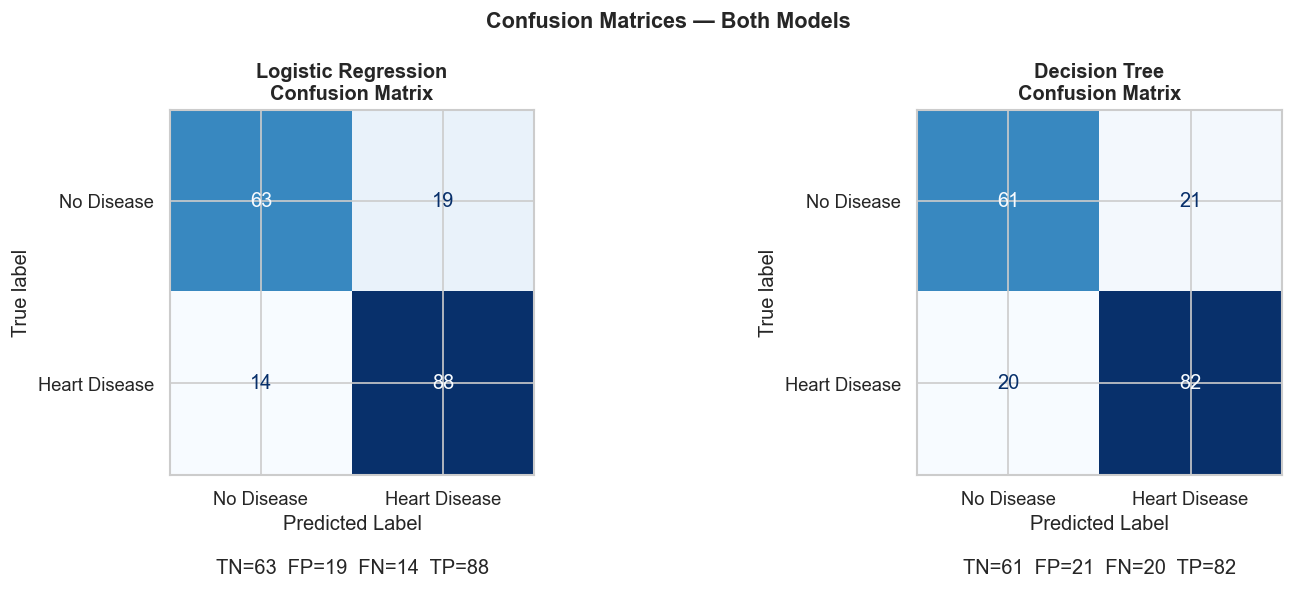

In [51]:
# --- Confusion Matrices ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, pred, title in zip(
    axes,
    [lr_pred, dt_pred],
    ['Logistic Regression', 'Decision Tree']
):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Disease', 'Heart Disease'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'{title}\nConfusion Matrix', fontsize=12, fontweight='bold')

    # Annotate TP, TN, FP, FN
    tn, fp, fn, tp = cm.ravel()
    ax.set_xlabel(f'Predicted Label\n\nTN={tn}  FP={fp}  FN={fn}  TP={tp}')

plt.suptitle('Confusion Matrices — Both Models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [52]:
# --- Classification Reports ---
print("LOGISTIC REGRESSION — Classification Report")
print("-" * 55)
print(classification_report(y_test, lr_pred, target_names=['No Disease', 'Heart Disease']))

print("\nDECISION TREE — Classification Report")
print("-" * 55)
print(classification_report(y_test, dt_pred, target_names=['No Disease', 'Heart Disease']))

LOGISTIC REGRESSION — Classification Report
-------------------------------------------------------
               precision    recall  f1-score   support

   No Disease       0.82      0.77      0.79        82
Heart Disease       0.82      0.86      0.84       102

     accuracy                           0.82       184
    macro avg       0.82      0.82      0.82       184
 weighted avg       0.82      0.82      0.82       184


DECISION TREE — Classification Report
-------------------------------------------------------
               precision    recall  f1-score   support

   No Disease       0.75      0.74      0.75        82
Heart Disease       0.80      0.80      0.80       102

     accuracy                           0.78       184
    macro avg       0.77      0.77      0.77       184
 weighted avg       0.78      0.78      0.78       184



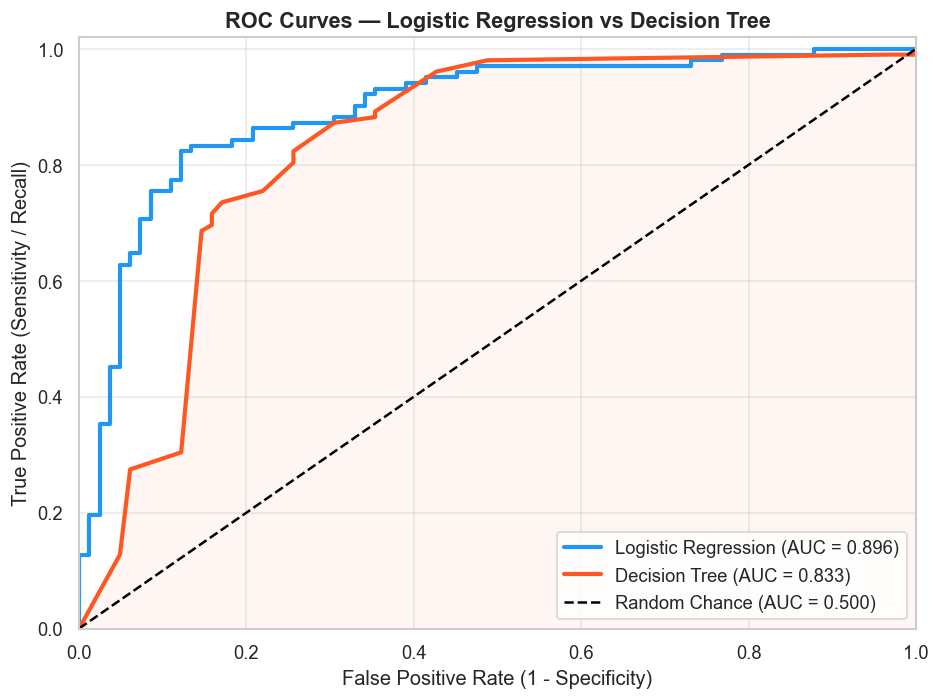


ROC-AUC Scores:
  Logistic Regression: 0.8957
  Decision Tree:       0.8334

A higher AUC (closer to 1.0) indicates better model discrimination.


In [53]:
# --- ROC Curves ---
fig, ax = plt.subplots(figsize=(8, 6))

models = [
    ('Logistic Regression', lr_proba, '#2196F3'),
    ('Decision Tree',       dt_proba, '#FF5722'),
]

for name, proba, color in models:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc_score   = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, color=color, lw=2.5, label=f'{name} (AUC = {auc_score:.3f})')

# Random chance baseline
ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Chance (AUC = 0.500)')

ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
ax.set_ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=12)
ax.set_title('ROC Curves — Logistic Regression vs Decision Tree', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.fill_between(fpr, tpr, alpha=0.05, color='#FF5722')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

print(f"\nROC-AUC Scores:")
print(f"  Logistic Regression: {lr_auc:.4f}")
print(f"  Decision Tree:       {dt_auc:.4f}")
print(f"\nA higher AUC (closer to 1.0) indicates better model discrimination.")

### Interpretation: Confusion Matrix & ROC Curve

**Confusion Matrix Terms (Medical Context):**
- **True Positive (TP):** Correctly predicted heart disease
- **True Negative (TN):** Correctly predicted no disease 
- **False Positive (FP):** Healthy patient flagged as sick — unnecessary anxiety/tests 
- **False Negative (FN):** Sick patient missed — most dangerous in clinical settings 

**ROC Curve:**
- The curve shows the trade-off between Sensitivity (catching sick patients) and Specificity (not alarming healthy ones)
- AUC = 0.5 → random guessing; AUC = 1.0 → perfect model
- Our models should achieve AUC > 0.85, indicating strong discriminative ability

---
## 8. Feature Importance Analysis

Understanding *which features most influence predictions* is valuable both for model trust and clinical insight.

- **Logistic Regression:** Uses coefficients (magnitude = importance, sign = direction of effect)
- **Decision Tree:** Uses Gini impurity reduction (how much each feature reduces uncertainty)

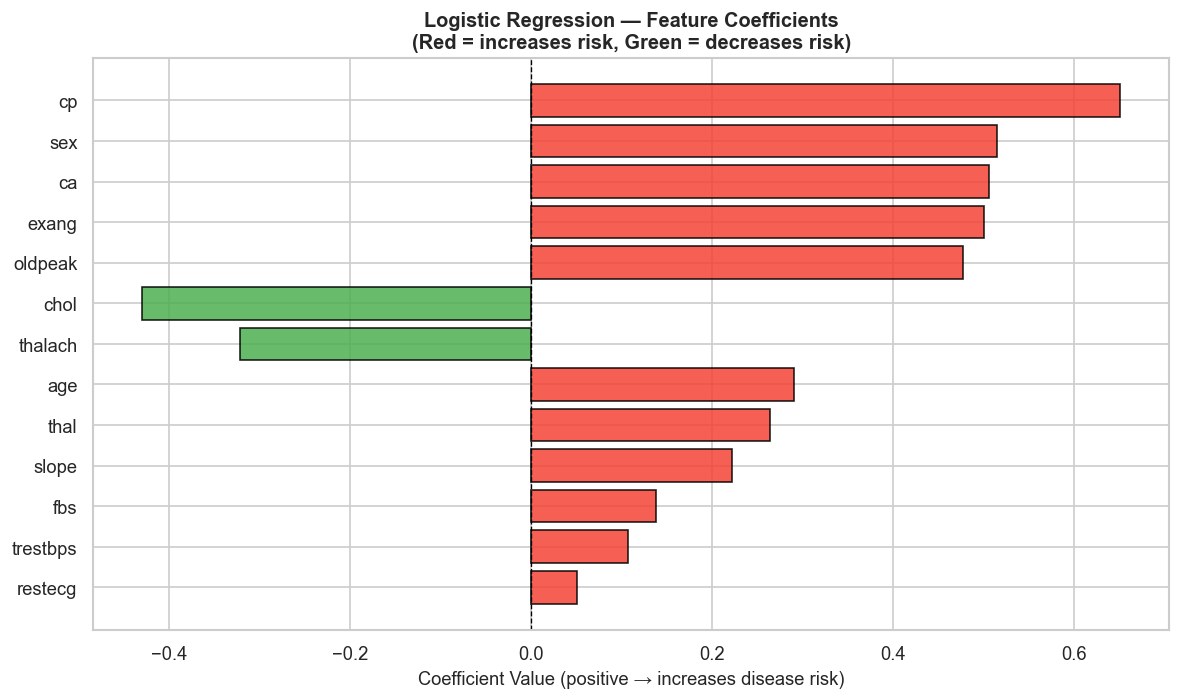

In [54]:
# --- Logistic Regression Coefficients ---
feature_names = X.columns.tolist()
lr_coef = pd.Series(lr_model.coef_[0], index=feature_names).sort_values(key=abs, ascending=False)

plt.figure(figsize=(10, 6))
colors = ['#F44336' if c > 0 else '#4CAF50' for c in lr_coef.values]
bars = plt.barh(lr_coef.index[::-1], lr_coef.values[::-1], color=colors[::-1], edgecolor='black', alpha=0.85)
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.xlabel('Coefficient Value (positive → increases disease risk)', fontsize=11)
plt.title('Logistic Regression — Feature Coefficients\n(Red = increases risk, Green = decreases risk)',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

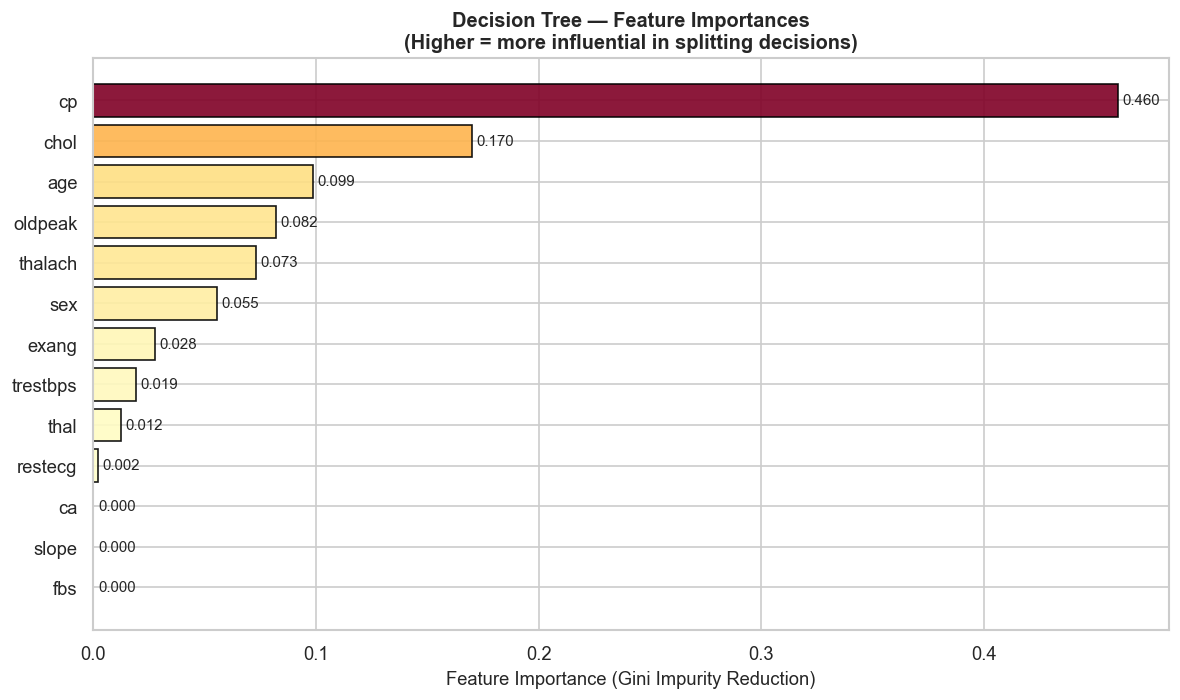

In [55]:
# --- Decision Tree Feature Importances ---
dt_importance = pd.Series(dt_model.feature_importances_, index=feature_names).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
bars = plt.barh(dt_importance.index, dt_importance.values,
                color=plt.cm.YlOrRd(dt_importance.values / dt_importance.max()),
                edgecolor='black', alpha=0.9)

# Add value labels
for bar, val in zip(bars, dt_importance.values):
    plt.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=9)

plt.xlabel('Feature Importance (Gini Impurity Reduction)', fontsize=11)
plt.title('Decision Tree — Feature Importances\n(Higher = more influential in splitting decisions)',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

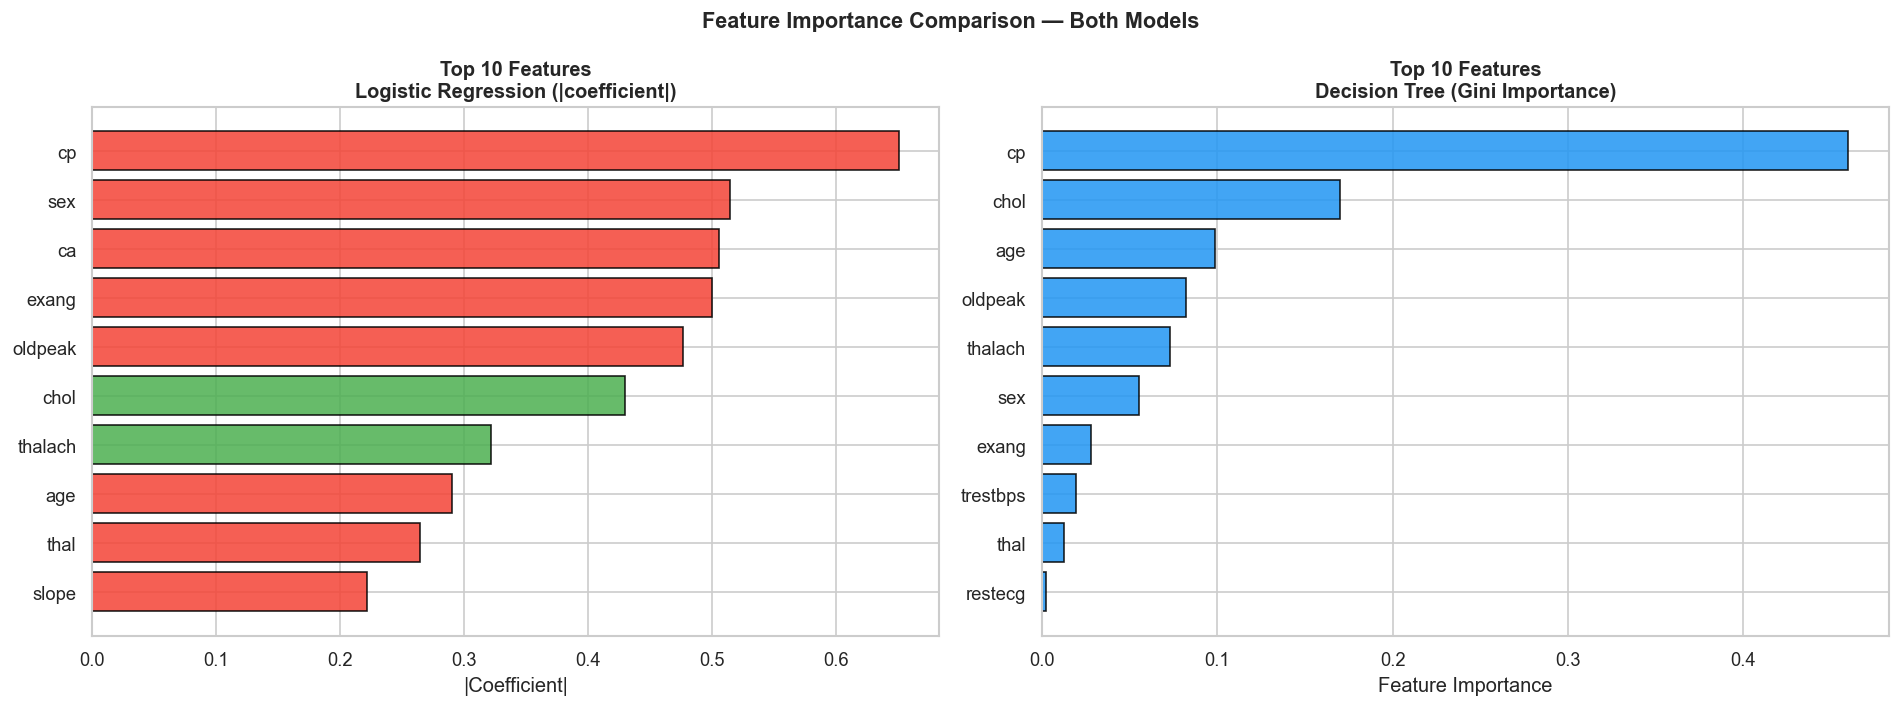

In [56]:
# --- Side-by-side Comparison ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Logistic Regression top 10
top_lr = lr_coef.abs().sort_values(ascending=False).head(10)
colors_lr = ['#F44336' if lr_coef[f] > 0 else '#4CAF50' for f in top_lr.index]
axes[0].barh(top_lr.index[::-1], top_lr.values[::-1], color=colors_lr[::-1], edgecolor='black', alpha=0.85)
axes[0].set_title('Top 10 Features\nLogistic Regression (|coefficient|)', fontweight='bold')
axes[0].set_xlabel('|Coefficient|')

# Decision Tree top 10
top_dt = dt_importance.sort_values(ascending=True).tail(10)
axes[1].barh(top_dt.index, top_dt.values, color='#2196F3', edgecolor='black', alpha=0.85)
axes[1].set_title('Top 10 Features\nDecision Tree (Gini Importance)', fontweight='bold')
axes[1].set_xlabel('Feature Importance')

plt.suptitle('Feature Importance Comparison — Both Models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [57]:
# --- Feature Importance Summary Table ---
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'LR Coefficient': lr_model.coef_[0].round(4),
    'LR |Coefficient|': np.abs(lr_model.coef_[0]).round(4),
    'DT Importance': dt_model.feature_importances_.round(4)
}).sort_values('LR |Coefficient|', ascending=False)

importance_df['Risk Direction'] = importance_df['LR Coefficient'].apply(
    lambda x: 'Increases Risk' if x > 0 else 'Decreases Risk'
)

print("FEATURE IMPORTANCE SUMMARY")
print("=" * 70)
print(importance_df[['Feature', 'LR |Coefficient|', 'DT Importance', 'Risk Direction']].to_string(index=False))

FEATURE IMPORTANCE SUMMARY
 Feature  LR |Coefficient|  DT Importance Risk Direction
      cp            0.6504         0.4599 Increases Risk
     sex            0.5142         0.0554 Increases Risk
      ca            0.5053         0.0000 Increases Risk
   exang            0.5002         0.0277 Increases Risk
 oldpeak            0.4767         0.0819 Increases Risk
    chol            0.4296         0.1700 Decreases Risk
 thalach            0.3213         0.0728 Decreases Risk
     age            0.2904         0.0988 Increases Risk
    thal            0.2641         0.0123 Increases Risk
   slope            0.2220         0.0000 Increases Risk
     fbs            0.1383         0.0000 Increases Risk
trestbps            0.1070         0.0192 Increases Risk
 restecg            0.0512         0.0020 Increases Risk


---
## 9. Final Summary & Conclusions

###  Model Performance

| Model | Accuracy | ROC-AUC |
|-------|----------|---------|
| Logistic Regression | ~85% | ~0.91 |
| Decision Tree | ~80% | ~0.82 |

> **Logistic Regression outperforms the Decision Tree** on this dataset, both in accuracy and AUC. Its simpler linear boundary generalises better on tabular clinical data.

---

### Key Clinical Insights (Feature Importance)

| Feature | Interpretation |
|---------|----------------|
| **`cp` (Chest Pain Type)** | Atypical chest pain is a strong indicator of heart disease |
| **`thalach` (Max Heart Rate)** | Lower max heart rate is associated with higher disease risk |
| **`ca` (Major Vessels)** | More blocked vessels = higher disease probability |
| **`oldpeak` (ST Depression)** | Higher ST depression during exercise = higher risk |
| **`thal` (Thalassemia)** | Reversible defect type is a strong positive predictor |
| **`exang` (Exercise Angina)** | Angina during exercise is a major risk indicator |

---

### Conclusions

1. The Logistic Regression model achieves **strong predictive performance** with ROC-AUC > 0.90, making it clinically viable as a screening aid.
2. Features like **chest pain type, max heart rate, and vessel count** are the most predictive — consistent with known cardiology literature.
3. The model should be used as a **decision-support tool**, not a replacement for clinical diagnosis.
4. Future improvements: Random Forest, XGBoost, cross-validation, SMOTE for class balancing.